In [9]:
%load_ext autoreload
%matplotlib widget

from helper_funcs import *
from collections import defaultdict
import numpy as np
import pandas as pd


dirs = get_dirs(root="C:\\Users\\setht\\Dropbox\\Citadel\\GitHub\\otocoherence")
dpi = 500

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
# Get data
def get_data(T_xi_types):
    data = defaultdict(lambda: defaultdict(dict))

    for T_xi_type in T_xi_types:
        # Read df
        df = pd.read_excel(os.path.join(
            dirs["results"], rf"soae_T_xi [{T_xi_type}].xlsx"
        ))

        dfs = {}
        dfs["P"] = df[df["mode"]=="P"]
        dfs["phi"] = df[df["mode"]=="phi"]
        has_P = not (len(dfs["P"]) == 0)

        # Gather everything into lists
        if "cgram" in T_xi_type:
            prop_list = ["T_xi", "species", "wf_idx", "f0", "PSD"]
            N_xi_multiplier = "f0"
        else:
            prop_list = ["T_xi", "species", "wf_idx", "f0_max", "f0_fit"]
            N_xi_multiplier = "f0_max"

        for mode in ["phi", "P"]:
            if not has_P and mode == "P":
                continue
            for prop in prop_list:
                data[T_xi_type][mode][prop] = np.array(dfs[mode][prop])
  
            # Calculate derived data
            data[T_xi_type][mode]["N_xi"] = data[T_xi_type][mode]["T_xi"] * data[T_xi_type][mode][N_xi_multiplier]
            data[T_xi_type][mode]["inv_T_xi"] = 1/(data[T_xi_type][mode]["T_xi"])
        if has_P:
            data[T_xi_type]["T_xi_diffs"] = data[T_xi_type]["P"]["T_xi"] - data[T_xi_type]["phi"]["T_xi"]
            data[T_xi_type]["N_xi_diffs"] = data[T_xi_type]["P"]["N_xi"] - data[T_xi_type]["phi"]["N_xi"]

    return data

# Define universal variables
# Peakc
bw_p = 10
df = 50
rip = 100
crop = 200
win_psd = "Hann"
tau_peakc_psd_ms = 500 
hop_peakc_psd_ms = 250 # Half of the tau
nfft_peakc_psd = None
# cgram
hop_cgram_ms = 10
tau_cgram_ms = 150 # Chosen because want a 10 Hz bandwidth; 
tau_cgram_psd_ms = tau_cgram_ms # PSD is the same for bin consistency
hop_cgram_psd_ms = 75 # Still half of tau
nfft_cgram = None
win_cgram = "Hann"
T_xi_type = "int 25ms"
delta_xi_ms = 1.0
xi_min_ms = delta_xi_ms
filter_meth = {'type':'kaiser', 'cf':300, 'df':50, 'rip':100}
hpf_str = get_filter_str(filter_meth)
rho = 1.0


peakc_filt_id = f"bw={bw_p}p max, kaiser, df={df}hz, rip={rip}db, crop={crop}hz, tau={tau_peakc_psd_ms}ms, hop_psd={hop_peakc_psd_ms}ms, nfft={nfft_peakc_psd}, win={win_psd}"
meth_id_cgram = f"cgram {T_xi_type}, delta_xi={delta_xi_ms}ms, rho={rho}, {win_cgram}, {hpf_str}, tau={tau_cgram_ms}ms, hop={hop_cgram_ms}ms, hop_psd={hop_cgram_psd_ms}ms, nfft={nfft_cgram}"

# Plotting parameters
markA='.'  # C_tau
markB='+'  # C_omega
markC='s'  # C_xi 
fontsize_ac = 14
dpi=500
fontsize_cgram = 40
labelpad = 20
fontsize_ticks = 20

lcc_kwargs = {
    "wf_len_s": 60,
    "filter_meth": filter_meth,
    "mode":'phi',
    "xi_min_s": xi_min_ms / 1000,
    "win_meth": {"method":"rho", "rho":rho, "win_type":win_cgram},
    "nfft": None,
    "pkl_folder": dirs["pickles"],
}

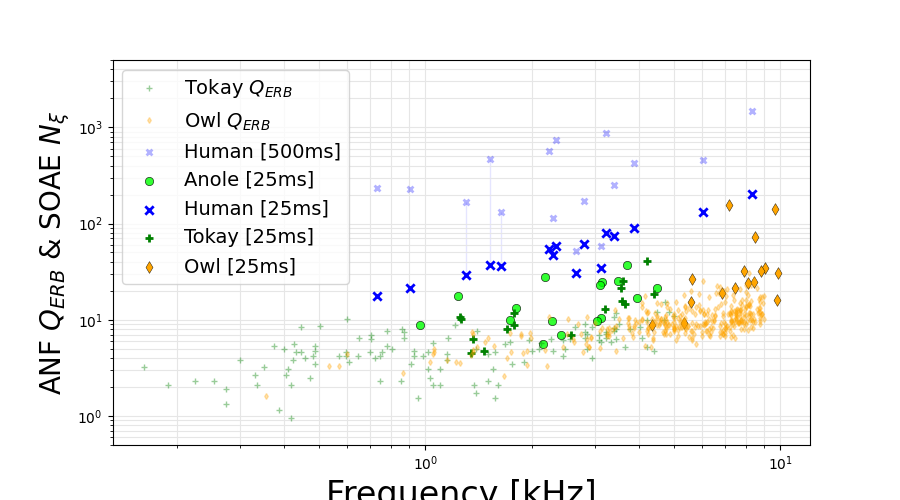

In [11]:
"Qerb and N_xi vs Freq"
meth_id_peak_centric = f"int 25ms, {peakc_filt_id}"
meth_id_peak_centric_long = f"int 500ms, {peakc_filt_id}"

data = get_data((meth_id_peak_centric, meth_id_peak_centric_long))
fig_fp_id = f"int {meth_id_peak_centric[4:8]} ({meth_id_peak_centric_long[4:8]} Human)"

alpha_human_long = 0.3
alpha_human_line = 0.1
s_human_long = 18
delta_mask_fmin, delta_mask_fmax = 1000, 2000
# delta_mask_fmin, delta_mask_fmax = 0, np.inf

for tc in ["N_xi"]:

    # ======================================================
    fig_fp = os.path.join(dirs["figs"], f"Qerb and {tc} vs Freq [{fig_fp_id}].jpg")


    # --- owl ANF tuning curve data (Excel files provided by Christine)
    fp_ANFfileOwl = os.path.join(dirs["data"], "Owl Qerb_analysis_CK2.xlsx")
    fp_ANFfileTokay = os.path.join(dirs["data"], "manley99.txt")
    # ======================================================


    # --- read in data
    owlANF = pd.read_excel(fp_ANFfileOwl)
    toakyANFq10 = np.loadtxt(fp_ANFfileTokay)

    # =========================
    # deal w/ owl ANF vals
    owlANF = owlANF[1:]  # discard first line
    freqANFowl = owlANF["CF"].values
    QerbANFowl = owlANF["Qerb"].values

    # =========================
    # deal w/ tokay ANF vals
    freqANFtokay = toakyANFq10[:, 0]
    QerbANFtokay = 6 * toakyANFq10[:, 1] * 1000 / np.pi
    # convert to Qerb(?) via Bergevin & Shera 2010

    if tc == "T_xi":
        QerbANFtokay, QerbANFowl = QerbANFtokay / freqANFtokay, QerbANFowl / freqANFowl

    # =======================================================================
    # ==== visualize
    plt.close("all")
    # ------------------------------------------------
    plt.figure(figsize=(9, 5))
    alphas = {"Anole": 0.8, "Owl": 1, "Human": 1, "Tokay": 1}
    markers = {"Anole": "o", "Owl": "d", "Human": "x", "Tokay": "+"}
    colors = {"Anole": "k", "Owl": "black", "Human": "blue", "Tokay": "green"}
    mews = {"Anole": 0.5, "Owl": 0.3, "Human": 2, "Tokay": 2}
    mfcs = {"Anole": "lime", "Owl": "orange", "Human": "blue", "Tokay": "green"}
    
    # Plot Q_ERB
    plt.plot(
        freqANFtokay,
        QerbANFtokay,
        "+",
        color="green",
        alpha=0.4,
        ms=4,
        lw=1,
        markerfacecolor="green",
        label=r"Tokay $Q_{ERB}$" if tc == "N_xi" else r"Tokay $Q_{ERB}/f$",
    )

    plt.plot(
        freqANFowl,
        QerbANFowl,
        "d",
        color="orange",
        alpha=0.3,
        ms=3,
        lw=1,
        markerfacecolor="orange",
        label=r"Owl $Q_{ERB}$" if tc == "N_xi" else r"Tokay $Q_{ERB}/f$",
    )

    # Plot Human
    human_mask = [sp == "Human" for sp in data[meth_id_peak_centric_long]["phi"]["species"]]
    plt.scatter(
            (data[meth_id_peak_centric_long]["phi"]["f0_max"] / 1000)[human_mask],
            data[meth_id_peak_centric_long]["phi"][tc][human_mask],
            marker=markers["Human"],
            color=colors["Human"],
            lw=mews["Human"],
            alpha=alpha_human_long,
            s=s_human_long,
            facecolors=mfcs["Human"],
            label=f"Human [{meth_id_peak_centric_long[4:9]}]",
        )
    
    # Plot deltas
    mask_deltas = [sp == "Human" and freq > delta_mask_fmin and freq < delta_mask_fmax for sp, freq in zip(data[meth_id_peak_centric]["phi"]["species"], data[meth_id_peak_centric]["phi"]["f0_max"])]
    plt.vlines(
        data[meth_id_peak_centric]["phi"]["f0_max"][mask_deltas] / 1000,
        ymin=np.minimum(data[meth_id_peak_centric]["phi"]["N_xi"][mask_deltas], data[meth_id_peak_centric_long]["phi"]["N_xi"][mask_deltas]),
        ymax=np.maximum(data[meth_id_peak_centric]["phi"]["N_xi"][mask_deltas], data[meth_id_peak_centric_long]["phi"]["N_xi"][mask_deltas]),
        lw=1,
        color="blue",
        zorder=0,
        alpha=alpha_human_line
    )


    # Plot X_xis
    for s in set(data[meth_id_peak_centric]["phi"]["species"]):
        mask_species = [sp == s for sp in data[meth_id_peak_centric]["phi"]["species"]]

        plt.scatter(
            (data[meth_id_peak_centric]["phi"]["f0_max"] / 1000)[mask_species],
            data[meth_id_peak_centric]["phi"][tc][mask_species],
            marker=markers[s],
            color=colors[s],
            lw=mews[s],
            alpha=alphas[s],
            s=36,
            facecolors=mfcs[s],
            label=f"{s} [{meth_id_peak_centric[4:8]}]",
        )
    




    # ---
    fsz=24
    plt.xscale("log")
    plt.yscale("log")
    # plt.xlim([0.1, 12])
    if tc=="N_xi":
        plt.ylim(0.5, 5e3)
    elif tc=="T_xi":
        plt.ylim(1e-3, 1e2)
    plt.xlabel("Frequency [kHz]", fontsize=fsz)
    plt.ylabel(rf"ANF $Q_{{ERB}}$ & SOAE ${tc[0]}_\xi$", fontsize=fsz-4)
    plt.legend(fontsize=fsz-10)
    ax = plt.gca()
    ax.set_axisbelow(True)
    plt.grid(True, which="both", ls="-", color="0.9")
    plt.savefig(fig_fp, dpi=dpi, bbox_inches="tight")
    plt.show()

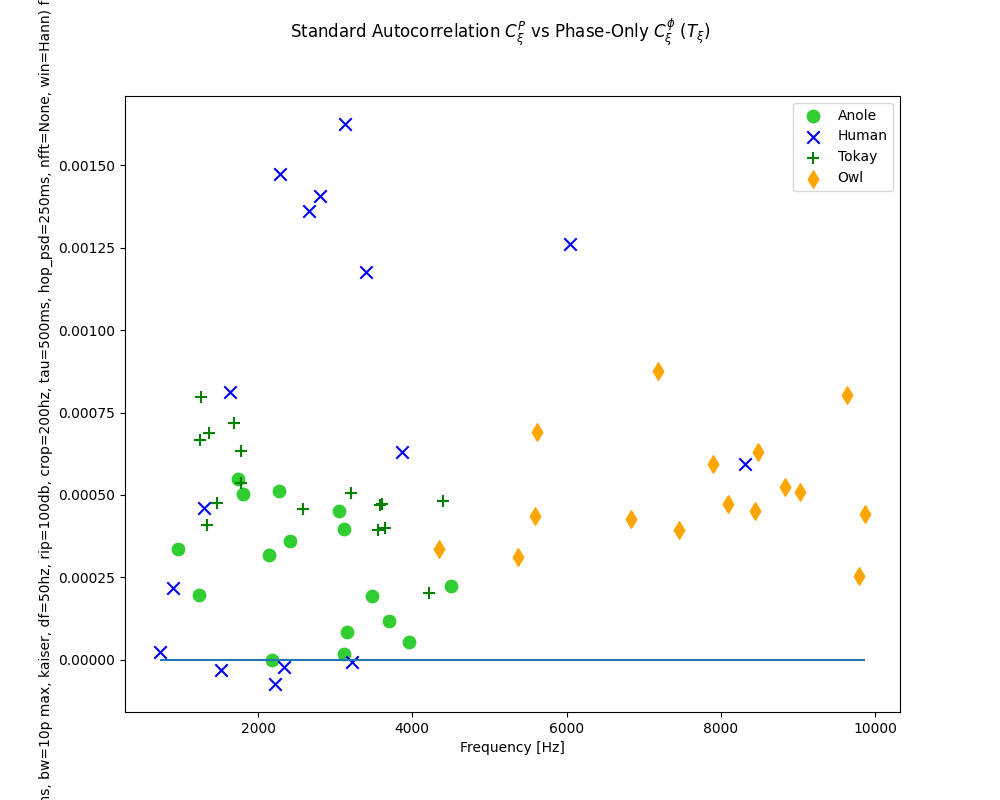

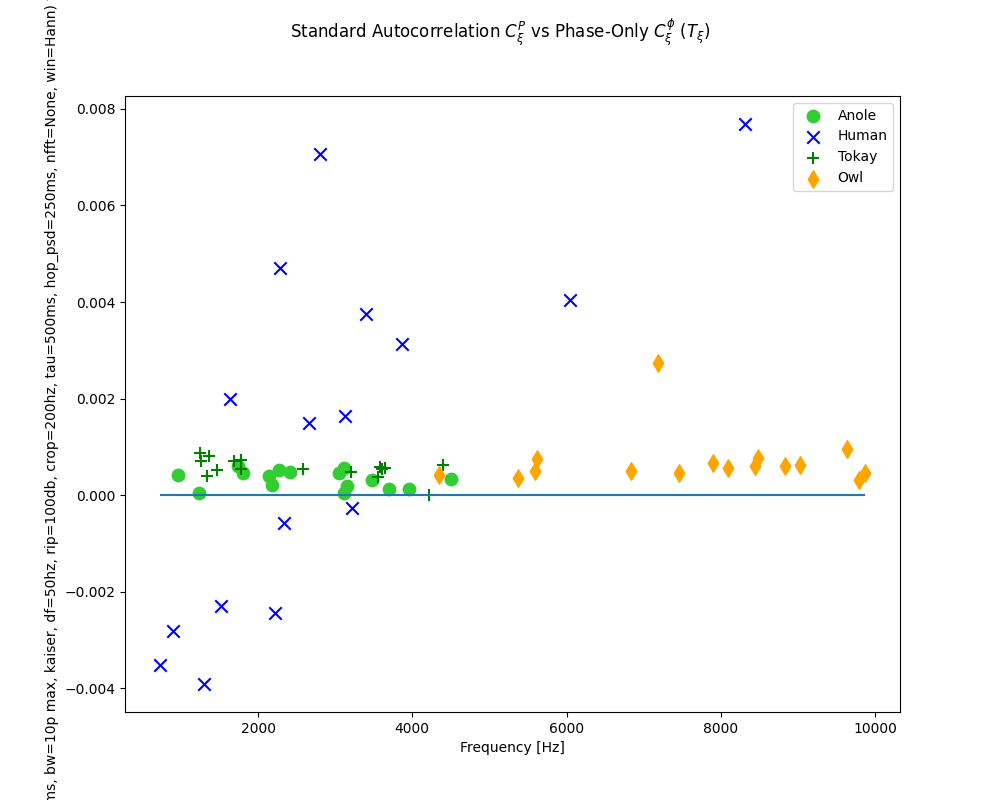

In [12]:
"Standard Autocorrelation vs Phase-Only"
T_xi_types = [f"int 25ms, {peakc_filt_id}", f"int 100ms, {peakc_filt_id}"]
data = get_data(T_xi_types)

for T_xi_type in T_xi_types:
    for tc in ["T_xi"]:
        # Initialize plot
        plt.figure(figsize=(10, 8))
        plt.suptitle(rf"Standard Autocorrelation $C_\xi^P$ vs Phase-Only $C_\xi^\phi$ (${tc[0]}_\xi$)")
        fn_plot = f'Phase only vs ACF ({tc[0]}_xi_{T_xi_type}).jpg'

        f0_maxs = data[T_xi_type]["P"]["f0_max"]
        speciess = data[T_xi_type]["P"]["species"]

        if np.max(np.abs(f0_maxs-data[T_xi_type]["phi"]["f0_max"])) > 0 or np.any(speciess != data[T_xi_type]["phi"]["species"]):
            raise ValueError("Frequencies and species should agree between modes!")


        markers = {
            "Anole": ("limegreen", "o"),
            "Owl": ("orange", "d"),
            "Human": ("blue", "x"),
            "Tokay": ("green", "+"),
        }

        unique_species = ["Anole", "Human", "Tokay", "Owl"]

        for species in unique_species:
            f0_maxs_plot = [this_f0_max for this_f0_max, this_species in zip(f0_maxs, speciess) if this_species == species]
            if tc == "N_xi":
                N_xi_diff_plot = [this_N_xi_diff for this_N_xi_diff, this_species in zip(data[T_xi_type]["N_xi_diffs"], speciess) if this_species == species]
                plt.scatter(f0_maxs_plot, N_xi_diff_plot, 
                            label=species,
                            color=markers[species][0],
                            marker=markers[species][1],
                            s=80)
            elif tc == "T_xi":
                T_xi_diff_plot = [this_T_xi_diff for this_T_xi_diff, this_species in zip(data[T_xi_type]["T_xi_diffs"], speciess) if this_species == species]
                plt.scatter(f0_maxs_plot, T_xi_diff_plot, 
                            label=species,
                            color=markers[species][0],
                            marker=markers[species][1],
                            s=80)
        plt.hlines(0, np.min(f0_maxs), np.max(f0_maxs))
        plt.xlabel("Frequency [Hz]")
        plt.ylabel(f"Time Constant ({T_xi_type}) from ACF - Phase Only")
        plt.legend()
        plt.savefig(os.path.join(dirs["figs"], fn_plot), dpi=dpi)

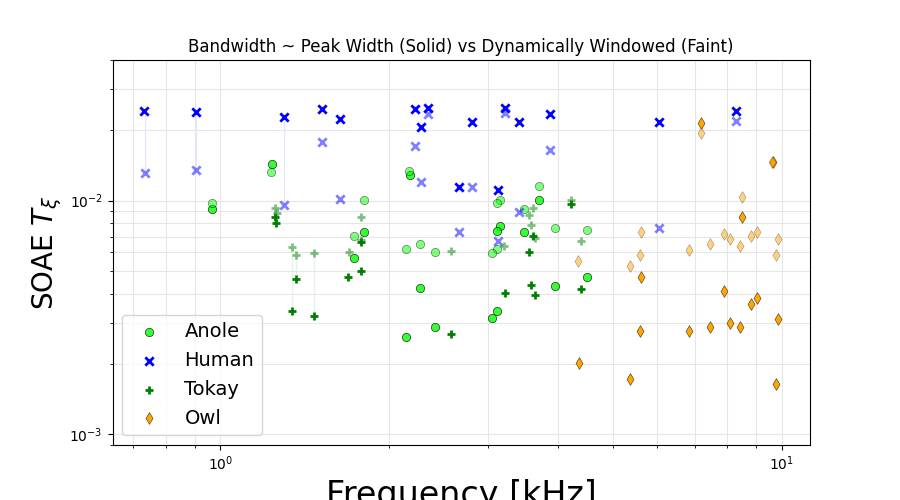

In [13]:
"N_xi from Cgram vs from peak-centric"
meth_id_peak_centric = f"int 25ms, {peakc_filt_id}"

data = get_data((meth_id_peak_centric, meth_id_cgram))

alpha_human_long = 0.3
alpha_human_line = 0.1
s_human_long = 18
delta_mask_fmin, delta_mask_fmax = 1000, 2000
# delta_mask_fmin, delta_mask_fmax = 0, np.inf

for tc in ["T_xi"]:

    # ======================================================
    fig_fp = os.path.join(dirs["figs"], f"Cgram vs Peak-centric {tc}.jpg")


    # --- owl ANF tuning curve data (Excel files provided by Christine)
    fp_ANFfileOwl = os.path.join(dirs["data"], "Owl Qerb_analysis_CK2.xlsx")
    fp_ANFfileTokay = os.path.join(dirs["data"], "manley99.txt")
    # ======================================================


    # --- read in data
    owlANF = pd.read_excel(fp_ANFfileOwl)
    toakyANFq10 = np.loadtxt(fp_ANFfileTokay)

    # =========================
    # deal w/ owl ANF vals
    owlANF = owlANF[1:]  # discard first line
    freqANFowl = owlANF["CF"].values
    QerbANFowl = owlANF["Qerb"].values

    # =========================
    # deal w/ tokay ANF vals
    freqANFtokay = toakyANFq10[:, 0]
    QerbANFtokay = 6 * toakyANFq10[:, 1] * 1000 / np.pi
    # convert to Qerb(?) via Bergevin & Shera 2010

    if tc == "T_xi":
        QerbANFtokay, QerbANFowl = QerbANFtokay / freqANFtokay, QerbANFowl / freqANFowl

    # =======================================================================
    # ==== visualize
    plt.close("all")
    # ------------------------------------------------
    plt.figure(figsize=(9, 5))
    alphas = {"Anole": 0.8, "Owl": 1, "Human": 1, "Tokay": 1}
    alphas_cgram = {"Anole": 0.5, "Owl": 0.5, "Human": 0.5, "Tokay": 0.5}
    markers = {"Anole": "o", "Owl": "d", "Human": "x", "Tokay": "+"}
    colors = {"Anole": "k", "Owl": "black", "Human": "blue", "Tokay": "green"}
    mews = {"Anole": 0.5, "Owl": 0.3, "Human": 2, "Tokay": 2}
    mfcs = {"Anole": "lime", "Owl": "orange", "Human": "blue", "Tokay": "green"}


    # Plot X_xis
    for s in set(data[meth_id_peak_centric]["phi"]["species"]):
        mask_species = [sp == s for sp in data[meth_id_peak_centric]["phi"]["species"]]
        mask_species_cgram = [sp == s for sp in data[meth_id_cgram]["phi"]["species"]]
        # Plot peak_centric ones for this species (easy part)
        f0_species_peak_centric = data[meth_id_peak_centric]["phi"]["f0_max"][mask_species]
        tc_species_peak_centric = data[meth_id_peak_centric]["phi"][tc][mask_species]

        plt.scatter(
            f0_species_peak_centric/1000,
            tc_species_peak_centric,
            marker=markers[s],
            color=colors[s],
            lw=mews[s],
            alpha=alphas[s],
            s=36,
            facecolors=mfcs[s],
            # label=f"{s} [{meth_id_peak_centric[4:8]}]",
            label=f"{s}"
        )
        for wf_idx in range(4):
            # Make wf_idx mask
            mask_idx = [idx == wf_idx for idx in data[meth_id_peak_centric]["phi"]["wf_idx"][mask_species]]
            mask_idx_cgram = [idx == wf_idx for idx in data[meth_id_cgram]["phi"]["wf_idx"][mask_species_cgram]]

            # Get the f0s from both methods so we can compare them
            peak_centric_f0s = data[meth_id_peak_centric]["phi"]["f0_max"][mask_species][mask_idx]
            cgram_f0s = data[meth_id_cgram]["phi"]["f0"][mask_species_cgram][mask_idx_cgram]

            # Make the cgram mask matching cgram values to the peak-centric values
            nearest_cgram_f0_idxs = np.argmin(np.abs(cgram_f0s[:, None] - peak_centric_f0s[None, :]), axis=0)
            mask_f0_cgram = np.zeros(len(cgram_f0s), dtype=bool) 
            mask_f0_cgram[nearest_cgram_f0_idxs] = True

            # Select cgram values using the mask
            f0s_species_idx_cgram = cgram_f0s[mask_f0_cgram]
            tc_species_idx_cgram = data[meth_id_cgram]["phi"][tc][mask_species_cgram][mask_idx_cgram][mask_f0_cgram]

            plt.scatter(
                (f0s_species_idx_cgram)/1000,
                tc_species_idx_cgram,
                marker=markers[s],
                color=colors[s],
                lw=mews[s],
                alpha=alphas_cgram[s],
                s=36,
                facecolors=mfcs[s],
                # label=f"{s} [{meth_id_peak_centric[4:8]}]",
            )

            # Plot deltas
            mask_deltas = [freq < 1500 for freq in f0s_species_idx_cgram]
            plt.vlines(
                f0s_species_idx_cgram[mask_deltas] / 1000,
                ymin=np.minimum(tc_species_idx_cgram[mask_deltas], tc_species_peak_centric[mask_idx][mask_deltas]),
                ymax=np.maximum(tc_species_idx_cgram[mask_deltas], tc_species_peak_centric[mask_idx][mask_deltas]),
                lw=1,
                color=colors[s],
                zorder=0,
                alpha=alpha_human_line
            )



    # ---
    fsz=24
    plt.xscale("log")
    plt.yscale("log")
    # plt.xlim([0.1, 12])
    if tc=="N_xi":
        plt.ylim(6, 300)
    elif tc=="T_xi":
        plt.ylim(9e-4, 4e-2)
    plt.xlabel("Frequency [kHz]", fontsize=fsz)
    plt.ylabel(rf"SOAE ${tc[0]}_\xi$", fontsize=fsz-4)
    plt.title(f"Bandwidth ~ Peak Width (Solid) vs Dynamically Windowed (Faint)")
    plt.legend(fontsize=fsz-10)
    ax = plt.gca()
    ax.set_axisbelow(True)
    plt.grid(True, which="both", ls="-", color="0.9")
    plt.savefig(fig_fp, dpi=dpi, bbox_inches="tight")
    plt.show()

Human
Filtering wf with cf=300Hz, df=50Hz, rip=100dB
Filtering took 6.851s
2048
1024
Owl
Filtering wf with cf=300Hz, df=50Hz, rip=100dB
Filtering took 8.912s
1024
512
Anole
Filtering wf with cf=300Hz, df=50Hz, rip=100dB
Filtering took 8.830s
1024
512
Tokay
Filtering wf with cf=300Hz, df=50Hz, rip=100dB
Filtering took 10.352s
1161
580


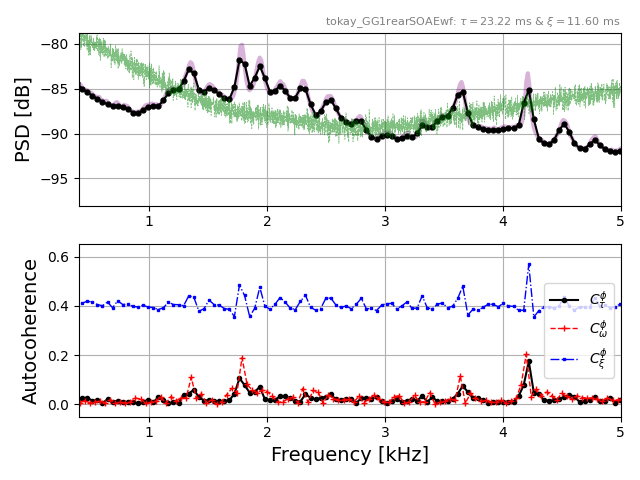

In [26]:
"Figure 2"
# Species dependent params
subjects = [('Human', 1), ('Owl', 3), ('Anole', 0), ('Tokay', 0)]
flims = {'Human':(0.4, 10), 'Owl':(2, 11), 'Anole':(0.4, 5), 'Tokay':(0.4, 5)}
yoff_hrs = {'Human':2.5, 'Owl':5.5, 'Anole':5.5, 'Tokay':5.5}
yoff_nfs = {'Human':-66, 'Owl':-61.5, 'Anole':-61.5, 'Tokay':-61.5}
# taus_C = {'Human':2048, 'Owl':1024, 'Anole':1024, 'Tokay':1161}
taus_C_mags_s = {'Human':0.04644, 'Owl':0.02322, 'Anole':0.02322, 'Tokay':0.02322}
# xis_C = {'Human':1024, 'Owl':512, 'Anole':512, 'Tokay':580}
xis_C_mags_s = {'Human':0.02322, 'Owl':0.01161, 'Anole':0.01161, 'Tokay':0.01161}
Cmins = {'Human':-0.05, 'Owl':-0.05, 'Anole':-0.05, 'Tokay':-0.05}
Cmin_xis = {'Human':-0.05, 'Owl':-0.05, 'Anole':-0.05, 'Tokay':-0.05}
Cmaxs = {'Human':1.05, 'Owl':0.9, 'Anole':0.65, 'Tokay':0.65}
Cmax_xis = {'Human':1.05, 'Owl':1.05, 'Anole':0.65, 'Tokay':0.65}

# Params in seconds
tau_mags_hr_s = 0.08
hop_mags_s = 0.01

# Colossogram
xi_max_ss = {'Human':1.0, 'Owl':0.1, 'Anole':0.1}
cgram_xmaxs = {'Human':1000, 'Owl':100, 'Anole':60}

# Load noise floor
nf_fp = os.path.join(dirs["data"], 'testSOAEsupp1.txt')   # file name
nf_data = np.loadtxt(nf_fp)
f_nf = nf_data[:,0]
mags_nf = nf_data[:,1]


for (species, wf_idx) in subjects:
    "First two rows"
    # Get waveform
    wf, wf_fn, fs = get_wf(species=species, wf_idx=wf_idx)
    print(species)
    # Preprocess
    wf-=np.mean(wf)
    wf=filter_wf_cgram(wf, fs, filter_meth)

    # Define win meth
    win_meth = {'method':'static', 'win_type':'boxcar'}

    # Get species-specific method parameters
    tau_C_mags = int(round(taus_C_mags_s[species] * fs))
    xi_C_mags = int(round(xis_C_mags_s[species] * fs))
    print(tau_C_mags)
    print(xi_C_mags)

    # Get species-specific plotting param
    flim = flims[species]
    yoff_hr = yoff_hrs[species] # Shift highres mags' "floating" dB scale up to line things up
    yoff_nf =  yoff_nfs[species] # Shift noisefloor mags' "floating" dB scale up to line things up
    Cmax = Cmaxs [species]
    Cmax_xi = Cmax_xis [species]
    Cmin = Cmins [species]
    Cmin_xi = Cmin_xis [species]

    # Get universal params in terms of this fs
    hop_cgram = int(round(hop_cgram_ms / 1000 * fs))
    hop_mags = int(round(hop_mags_s * fs))
    tau_cgram = int(round(tau_cgram_ms / 1000 * fs))
    tau_mags_hr = int(round(tau_mags_hr_s * fs))


    # Calculate PSD and high res version
    f_lr, mags_lr = pc.get_welch(wf, fs, tau_C_mags, hop=hop_mags, avg_exp=1, win=win_psd.lower()) 
    f_hr, mags_hr = pc.get_welch(wf, fs, tau_mags_hr, hop=hop_mags, avg_exp=1, win=win_psd.lower())

    # Convert to dB
    mags_lr, mags_hr = 20*np.log10(mags_lr), 20*np.log10(mags_hr)
    # Calculate autocoherences
    C_xi_phi = pc.get_autocoherence(wf, fs, xi=xi_C_mags, tau=tau_C_mags, win_meth=win_meth, mode='phi')[1]
    C_tau_phi = pc.get_autocoherence(wf, fs, xi=tau_C_mags, tau=tau_C_mags, win_meth=win_meth, mode='phi')[1]
    f_omega, C_omega_phi = pc.get_autocoherence(wf, fs, xi=xi_C_mags, tau=tau_C_mags, win_meth=win_meth, mode='phi', ref_type='freq', freq_bin_hop=1)
    
    # freq. limits for plotting [kHz]
    fmin, fmax = flim[0], flim[1]
    fmin_idx, fmax_idx = np.argmin(np.abs(f_lr-fmin*1000)), np.argmin(np.abs(f_lr-fmax*1000))
    if species not in ['Owl', 'Tokay']:
        title = rf"{species.lower()}_{wf_fn[:-4]}: $\tau={1000*tau_C_mags/fs:.2f}$ ms & $\xi={1000*xi_C_mags/fs:.2f}$ ms"
    else:
        title = rf"{wf_fn[:-4]}: $\tau={1000*tau_C_mags/fs:.2f}$ ms & $\xi={1000*xi_C_mags/fs:.2f}$ ms"

    ylim_pad=[6,3] # Ylimit padding below/above mags on ylimits

    # Initialize plot
    plt.close('all')
    fig, ax = plt.subplots(2, 1, figsize=(6.4, 4.8))

    "Magnitude Subplot"
    ax[0].plot(f_hr/1000,mags_hr+yoff_hr,linestyle='-', lw=3,
                    color='purple',alpha=0.3,label='PSD (High Res.)')
    # === mags. on top
    ax[0].plot(f_lr/1000,mags_lr,linestyle='-', marker=markA, 
                    ms=7,color='k',label='PSD')

    # -- include mic noise floor
    ax[0].plot(f_nf/1000,mags_nf+yoff_nf,linestyle='--',color='g',lw=0.5,
                alpha=0.5,label='Est. Noise Floor')
    #
    #ax5[0].set_xlabel('Frequency [kHz]')  
    fracLS= 0.05  # scaling fraction to help w/ vert. lims {0.05}
    ax[0].set_ylabel('PSD [dB]',fontsize=fontsize_ac)
    ax[0].set_title(title,fontsize=8,loc='right',color=[0.5,0.5,0.5]) 
    ax[0].set_xlim(fmin, fmax)
    # ax[0].legend(loc="upper right")
    ax[0].grid()
    ax[0].set_ylim([np.min(mags_lr[fmin_idx:(fmax_idx+1)])-ylim_pad[0],
                    np.max(mags_lr[fmin_idx:(fmax_idx+1)])+ylim_pad[1]])


    "Autocoherence Subplot"
    # ===  coherence on bottom
    Lb1= ax[1].plot(f_lr/1000,C_tau_phi,linestyle='-', 
                    marker=markA,color='k',label=r'$C_\tau^\phi$')
    Lb2= ax[1].plot(f_omega/1000, C_omega_phi,'r',lw=1,linestyle='--',
                    marker=markB,label=r'$C_\omega^\phi$',markersize=4)
    # --- use right y-axis for C_xi
    # ax5b = ax[1].twinx()
    # Lb3= ax5b.plot(f/1000,C_xi_phi,'b',lw=1,linestyle='-.', marker=markC,label=r'$C_\xi^\phi$',markersize=2)
    Lb3 = ax[1].plot(f_lr/1000,C_xi_phi,'b',lw=1,linestyle='-.',
                    marker=markC,label=r'$C_\xi^\phi$',markersize=2)

    # same axis limits on both sides
    # ax5b.set_ylim([Cmin_xi,Cmax_xi])
    ax[1].set_xlabel('Frequency [kHz]',fontsize=fontsize_ac)  
    # ax[1].set_ylabel(r'Autocoherence ($C_\tau^\phi$ & $C_\omega^\phi$)',fontsize=fontsize_ac) 
    ax[1].set_ylabel(r'Autocoherence',fontsize=fontsize_ac) 
    # ax5b.set_ylabel(r'Autocoherence ($C_{\xi}^\phi$)',fontsize=12,color='b') 
    ax[1].grid()
    ax[1].set_xlim(fmin, fmax)
    ax[1].set_ylim([Cmin,Cmax])
    LbT = Lb1+Lb2+Lb3  # deal w/ legend given multiple ordinates
    labelF5 = [l.get_label() for l in LbT]
    ax[1].legend(LbT,labelF5,loc="center right")
    plt.tight_layout()
    plt.savefig(os.path.join(dirs["figs"], f'Fig2R1 ({species}).jpg'), dpi=dpi, bbox_inches='tight')

    "Colossogram Plot"
    fp_pp = os.path.join(dirs["results"], "picked_peaks.json")
    picked_peaks = get_picked_peaks(fp_pp, wf_fn)

    # # Load Colossogram
    # cgram_dict = load_calc_colossogram(
    #     **(
    #         lcc_kwargs
    #         | {
    #             "xi_max_s": xi_max_ss[species],
    #             "species": species,
    #             "fs": fs,
    #             "tau": tau_cgram,
    #             "hop": hop_cgram,
    #             "wf": wf,
    #             "wf_idx": wf_idx,
    #             "wf_fn": wf_fn,
    #         }
    #     )
    # )


    # # Load everything that wasn't explicitly "saved" in the filename
    # colossogram = cgram_dict["colossogram"]
    # fn_id = cgram_dict["fn_id"]
    # win_meth_str = cgram_dict["win_meth_str"]
    # method_id = cgram_dict["method_id"]
    # filter_str = cgram_dict["filter_str"]
    # f_cgram = cgram_dict["f"]
    # xis_s = cgram_dict["xis_s"]
    # # good_peak_idxs = np.argmin(np.abs(f[:, None] - good_peak_freqs[None, :]), axis=0)
    # # method_id = rf"[$\tau$={(tau/fs)*1000:.2f}ms]   [Mode=$\phi$]   [{win_meth_str}]   [Hop={hop_s*1000:.1f}ms]   [{N_pd_str}]   [nfft={nfft}]"
    # # suptitle = (
    # #     rf"[{species} {wf_idx}]   [{wf_fn}]   [HPBW={bw}Hz]   {method_id}   [{filter_str}]"
    # # )
    # suptitle=None

    # # MAKE PLOT
    # plt.figure(figsize=(18, 10))
    # cbar = pc.plot_colossogram(cgram_dict, cmap="bone_r", return_cbar=True)
    # # Set Chris' requested fontsizes
    # ax = plt.gca()
    # ax.set_xlabel(r"$\xi$ [ms]", labelpad=labelpad, fontsize=fontsize_cgram)
    # ax.set_ylabel("Frequency [kHz]", labelpad=labelpad, fontsize=fontsize_cgram)
    # ax.tick_params(axis='both', which='major', length=10, width=2)
    # ax.tick_params("both", labelsize=fontsize_cgram)
    # cbar.ax.yaxis.label.set_fontsize(fontsize_cgram)
    # cbar.ax.tick_params(labelsize=fontsize_cgram)
    # if species != 'Human':
    #     cbar.ax.remove()

    # xmin = xis_s[0] * 1000
    # xmax = cgram_xmaxs[species]
    # plt.ylim(fmin, fmax)
    # plt.xlim(xmin, xmax)

    # for f0_idx in picked_peaks:
    #     plt.scatter(
    #         xmin / 2,
    #         f_cgram[f0_idx] / 1000,
    #         c="purple",
    #         marker=">",
    #         label="Peak at " + f"{f_cgram[f0_idx]:0f}Hz",
    #         alpha=0.5,
    #         s=100
    #     )

    # # plt.title(f"Colossogram", fontsize=18)
    # # plt.suptitle(suptitle, fontsize=10)
    # plt.tight_layout()
    # plt.savefig(
    #     os.path.join(dirs["figs"], f"Fig2R2 ({species}).jpg"),
    #     dpi=dpi,
    # )


    
    

In [ ]:
"T_xi specs"
data_cgram = get_data([meth_id_cgram])[meth_id_cgram]["phi"]
df_cgram = pd.DataFrame(data_cgram)

fsz = 24
figsize = (10, 5)
alpha_sig = 1
alpha_insig = 0.25
s_sig = 5
s_insig = 1

flims = {'Anole':[1, 6], 'Human':[1, 10], 'Owl':[1, 12], 'Tokay':[1, 6]}
T_xi_thresh = 0.005

for species, wf_idx in (('Human', 1), ('Owl', 3), ('Anole', 0), ('Tokay', 0)):
    wf_fn = get_wf_fn(species=species, wf_idx=wf_idx)
    df_sidx = df_cgram[(data_cgram["species"] == species) & (data_cgram["wf_idx"] == wf_idx)]
    f_lr = df_sidx["f0"]
    T_xi = df_sidx["T_xi"]
    psd = df_sidx["PSD"]

    fmin, fmax = (np.array(flims[species]))*1000  
    fmin_idx = np.argmin(np.abs(f_lr-fmin))
    fmax_idx = np.argmin(np.abs(f_lr-fmax))
    T_xis_idxs = np.arange(len(T_xi))
    sig_mask = (T_xi >= T_xi_thresh) & (T_xis_idxs > fmin_idx) & (T_xis_idxs < fmax_idx)

    
    fmin_idx_plot, fmax_idx_plot = np.argmin(np.abs(f_lr-fmin)), np.argmin(np.abs(f_lr-fmax))
    f_plot = f_lr[fmin_idx_plot:fmax_idx_plot]
    sig_mask_plot = sig_mask[fmin_idx_plot:fmax_idx_plot]
    T_xis_plot = T_xi[fmin_idx_plot:fmax_idx_plot]

    # Plot PSD 
    psd_plot = psd[fmin_idx_plot:fmax_idx_plot]
    psd_db_plot = 10*np.log10(psd_plot)
    plt.close('all')
    plt.figure(figsize=figsize) 
    plt.ylabel(rf"PSD [dB]", color="orange", fontsize=fsz)
    plt.xlabel("Frequency [Hz]", fontsize=fsz)
    plt.plot(f_plot, psd_db_plot, color="orange")

    # Plot T_xi Spectrum
    plt.twinx()
    plt.scatter(f_plot[sig_mask_plot], T_xis_plot[sig_mask_plot], s=s_sig, alpha=alpha_sig, color="purple")
    plt.scatter(f_plot[~sig_mask_plot], T_xis_plot[~sig_mask_plot], s=s_insig, alpha=alpha_insig, color="purple")
    plt.ylabel(rf"$T_\xi$ [s]", color="purple", fontsize=fsz)
    plt.tight_layout()
    plt.title(wf_fn, loc="right", alpha=0.5)
    fn_T_xi_spec = f"T_xi Spectrum - {species} {wf_idx}.jpg"
    plt.savefig(os.path.join(dirs["figs"], fn_T_xi_spec), dpi=dpi)